Phase 2

In [86]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

 
print(os.listdir("/content/drive/MyDrive/ColabProjects/"))
path="/content/drive/MyDrive/ColabProjects/yellow_tripdata_2025-09.parquet"

['Tree_Inventory_20250908.csv', 'BuffaloInventory.ipynb', 'Pramola_BonusAssignment_BuffaloInventory.ipynb', 'Pramola_Workshop_AssignmentBonus.ipynb', 'Pramola_assignment0_final.ipynb', 'Untitled0.ipynb', 'pramola_DIC_Assignment1.ipynb', 'HW1_Pramola_50674837.ipynb', 'noisy_datasets (1).zip', 'noisy_datasets', 'Assignment1_PradeepRamola_SwatiBhatt.ipynb', 'flowers.zip', 'tip_prediction', 'payment_prediction', 'payment_prediction.pt', 'tip_prediction.pt', 'yellow_tripdata_2025-09.parquet']


In [88]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# Stop active session if exists
active = SparkSession.getActiveSession()
if active:
    active.stop()

spark = SparkSession.builder \
    .appName("NYC_Taxi_App") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.local.ip", "127.0.0.1") \
    .config("spark.ui.port", "0") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

sc = spark.sparkContext

df_raw = spark.read.parquet(path)
df_raw.printSchema()
df_raw.show(5)


root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

+--------+--------------------+---------------------+---------------+------

Data Cleaning

In [89]:
df = (df_raw
      .withColumn("tpep_pickup_datetime", to_timestamp("tpep_pickup_datetime"))
      .withColumn("tpep_dropoff_datetime", to_timestamp("tpep_dropoff_datetime"))
      .withColumn("trip_duration_min",
                  (col("tpep_dropoff_datetime").cast("long") -
                   col("tpep_pickup_datetime").cast("long")) / 60.0)
)


In [90]:
df = (df
      .filter(col("trip_distance") > 0)
      .filter(col("trip_distance") < 100)
      .filter(col("trip_duration_min") > 0)
      .filter(col("trip_duration_min") < 240)             # 4 hours upper cap
      .filter(col("passenger_count") > 0)
      .filter(col("total_amount") > 0)
)


In [91]:
from pyspark.sql.functions import when


numeric_cols = ["fare_amount", "extra", "mta_tax", "tip_amount",
                "tolls_amount", "improvement_surcharge",
                "total_amount", "congestion_surcharge", "Airport_fee",
                "cbd_congestion_fee"]


df = df.fillna(0, subset=numeric_cols)


EDA

In [92]:
df.select("trip_distance", "trip_duration_min", "total_amount",
          "tip_amount", "passenger_count").describe().show()


+-------+-----------------+--------------------+------------------+------------------+------------------+
|summary|    trip_distance|   trip_duration_min|      total_amount|        tip_amount|   passenger_count|
+-------+-----------------+--------------------+------------------+------------------+------------------+
|  count|          2988318|             2988318|           2988318|           2988318|           2988318|
|   mean|3.534073063843746|  18.273519546224414|30.666790264630357|3.8193811535449216|1.2704253697230348|
| stddev|4.629679447832629|  15.640460135090995| 188.7969790607895| 4.218331380429885|0.6684844702954211|
|    min|             0.01|0.016666666666666666|               0.5|               0.0|                 1|
|    max|            98.84|               239.6|         323820.17|             400.0|                 8|
+-------+-----------------+--------------------+------------------+------------------+------------------+



In [93]:
quantiles = df.approxQuantile("total_amount", [0.25, 0.5, 0.75, 0.9], 0.01)
print("25%, 50%, 75%, 90%:", quantiles)


25%, 50%, 75%, 90%: [17.15, 22.38, 32.82, 58.94]


In [94]:
df_tip_dist = (df
               .groupBy(
                    (round(col("trip_distance"), 0).alias("trip_distance_bin"))
                )
               .agg(avg("tip_amount").alias("avg_tip"))
               .orderBy("trip_distance_bin"))
df_tip_dist.show(20)


+-----------------+------------------+
|trip_distance_bin|           avg_tip|
+-----------------+------------------+
|              0.0| 1.941069622512463|
|              1.0| 2.314555760298237|
|              2.0|3.1196464112441125|
|              3.0| 3.823857892696539|
|              4.0| 4.333040131171203|
|              5.0| 4.663485891875001|
|              6.0| 4.909913512430456|
|              7.0| 5.381929251077532|
|              8.0| 6.431410334744459|
|              9.0| 7.726513611080439|
|             10.0| 8.077154286676782|
|             11.0|  7.97956057840792|
|             12.0| 7.846330501169846|
|             13.0| 7.558731742779733|
|             14.0|  7.43591453922787|
|             15.0| 8.435036274800057|
|             16.0|   10.215713467645|
|             17.0|11.416762038258396|
|             18.0|11.644019492850587|
|             19.0|11.487432804634663|
+-----------------+------------------+
only showing top 20 rows



In [95]:
df.groupBy("payment_type").count().orderBy(desc("count")).show()


+------------+-------+
|payment_type|  count|
+------------+-------+
|           1|2587054|
|           2| 335400|
|           4|  52038|
|           3|  13826|
+------------+-------+



In [96]:
df_time = df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))

df_time.groupBy("pickup_hour", "payment_type") \
       .count() \
       .orderBy("pickup_hour", "payment_type") \
       .show()


+-----------+------------+-----+
|pickup_hour|payment_type|count|
+-----------+------------+-----+
|          0|           1|68941|
|          0|           2| 7958|
|          0|           3|  421|
|          0|           4| 1858|
|          1|           1|42802|
|          1|           2| 4813|
|          1|           3|  281|
|          1|           4| 1137|
|          2|           1|27494|
|          2|           2| 3152|
|          2|           3|  195|
|          2|           4|  751|
|          3|           1|17107|
|          3|           2| 2137|
|          3|           3|  139|
|          3|           4|  543|
|          4|           1|11327|
|          4|           2| 2023|
|          4|           3|  125|
|          4|           4|  456|
+-----------+------------+-----+
only showing top 20 rows



In [97]:
median_fare = df.approxQuantile("total_amount", [0.5], 0.01)[0]

df = df.withColumn("high_fare",
                   (col("total_amount") >= median_fare).cast("int"))

df.groupBy("high_fare").agg(
    avg("trip_distance").alias("avg_trip_distance"),
    avg("trip_duration_min").alias("avg_duration")
).show()


+---------+------------------+------------------+
|high_fare| avg_trip_distance|      avg_duration|
+---------+------------------+------------------+
|        1| 5.859367341294331|27.782267201816914|
|        0|1.1546424223712914| 8.543393878622334|
+---------+------------------+------------------+



Machine Learning Models

feature engineering

In [98]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline



df_ml = (df
         .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
         .withColumn("pickup_day_of_week", dayofweek("tpep_pickup_datetime"))
)


numeric_features = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "fare_amount", "tolls_amount", "improvement_surcharge",
    "congestion_surcharge", "Airport_fee", "cbd_congestion_fee"
]

categorical_features = [
    "VendorID", "RatecodeID", "PULocationID", "DOLocationID",
    "pickup_hour", "pickup_day_of_week"
]

indexers = [
    StringIndexer(inputCol=col_name, outputCol=col_name + "_idx", handleInvalid="keep")
    for col_name in categorical_features
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_features],
    outputCols=[c + "_ohe" for c in categorical_features]
)

assembler = VectorAssembler(
    inputCols=numeric_features + [c + "_ohe" for c in categorical_features],
    outputCol="features"
)


Problem 1 – High vs Low Fare (Classification)

In [99]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

# Train-test split
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="high_fare",
    maxIter=20
)

pipeline_clf_fare = Pipeline(stages=indexers + [encoder, assembler, lr])

# Simple hyperparameter tuning example
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.0, 0.01, 0.1])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .build())

evaluator_bin = BinaryClassificationEvaluator(
    labelCol="high_fare",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

tvs = TrainValidationSplit(
    estimator=pipeline_clf_fare,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_bin,
    trainRatio=0.8
)

model_fare = tvs.fit(train_df)
predictions_fare = model_fare.transform(test_df)

auc = evaluator_bin.evaluate(predictions_fare)
print("High vs Low Fare AUC:", auc)


High vs Low Fare AUC: 0.9880296295496955


In [100]:
model_fare.write().overwrite().save("/content/drive/MyDrive/ColabProjects/high_low_fare_prediction")

In [101]:
import shutil

src = "/content/drive/MyDrive/ColabProjects/high_low_fare_prediction"
dst = "/content/drive/MyDrive/ColabProjects/high_low_fare_prediction_zip"

# Create ZIP archive
shutil.make_archive(dst, 'zip', src)

print("Saved as:", dst + ".zip")


Saved as: /content/drive/MyDrive/ColabProjects/high_low_fare_prediction_zip.zip


In [102]:
from google.colab import files
files.download("/content/drive/MyDrive/ColabProjects/high_low_fare_prediction_zip.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(
    labelCol="high_fare",
    predictionCol="prediction",
    metricName="accuracy"
)
print("Accuracy:", acc_eval.evaluate(predictions_fare))


Accuracy: 0.9396198260561177


Problem 2 – Tip Amount Prediction (Regression)

In [15]:
df_tip = df_ml.filter(col("tip_amount").isNotNull())

In [16]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml import Pipeline

# 10% sample
df_tip_sample = df_tip.sample(fraction=0.1, seed=42)
train_tip, test_tip = df_tip_sample.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="tip_amount",
    maxDepth=5,
    numTrees=20
)

pipeline_tip = Pipeline(stages=indexers + [encoder, assembler, rf])

paramGrid_rf = (ParamGridBuilder()
                .addGrid(rf.maxDepth, [5, 8])
                .addGrid(rf.numTrees, [20, 50])
                .build())

evaluator_reg = RegressionEvaluator(
    labelCol="tip_amount",
    predictionCol="prediction",
    metricName="rmse"
)

tvs_tip = TrainValidationSplit(
    estimator=pipeline_tip,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_reg,
    trainRatio=0.8
)

model_tip = tvs_tip.fit(train_tip)
pred_tip = model_tip.transform(test_tip)

rmse = evaluator_reg.evaluate(pred_tip)
mae = RegressionEvaluator(
    labelCol="tip_amount",
    predictionCol="prediction",
    metricName="mae"
).evaluate(pred_tip)
r2 = RegressionEvaluator(
    labelCol="tip_amount",
    predictionCol="prediction",
    metricName="r2"
).evaluate(pred_tip)

print("Tip prediction RMSE:", rmse)
print("Tip prediction MAE:", mae)
print("Tip prediction R2:", r2)


Tip prediction RMSE: 3.1402294446898935
Tip prediction MAE: 1.9183484117146303
Tip prediction R2: 0.4581064600480915


In [17]:
pred_tip.select("tip_amount", "prediction").show(10)


+----------+------------------+
|tip_amount|        prediction|
+----------+------------------+
|       2.7| 2.115634908573654|
|      3.33|2.5861008685364535|
|      2.75|2.1915982054444516|
|       5.0|  8.25363031295024|
|       0.0|   3.1959060105224|
|       5.1| 3.744178096398271|
|      4.65|3.5285069337864576|
|      3.25|1.7716472131941325|
|       3.3|2.5861008685364535|
|      10.0|12.449886245499266|
+----------+------------------+
only showing top 10 rows



In [18]:
rf_model = model_tip.bestModel.stages[-1]
print(rf_model.featureImportances)


(548,[0,1,2,3,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,57,58,59,60,61,62,64,65,66,67,69,70,71,72,75,76,77,80,83,84,85,86,89,91,93,95,96,97,100,103,105,106,107,111,112,115,118,120,121,123,125,128,133,144,146,148,150,155,157,176,187,189,199,207,213,214,215,221,229,232,234,254,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,301,302,303,304,305,306,307,308,309,310,311,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,350,351,352,353,354,356,357,358,359,360,361,362,364,365,366,367,368,370,371,374,375,376,377,378,379,380,383,384,385,386,387,388,389,391,392,393,394,395,396,398,401,402,403,404,405,406,407,408,411,412,414,416,418,419,422,424,425,428,429,430,431,432,433,435,436,437,43

In [ ]:
from pyspark.ml.linalg import DenseVector

importances = rf_model.featureImportances

 
numeric_features = ['fare_amount', 'trip_distance', 'trip_duration_min', 'tolls_amount', 'Airport_fee']
 
ohe_features = {
    'pickup_hour_ohe': 24,
    'PULocationID_ohe': 263,
    'DOLocationID_ohe': 260
}

 
for idx, imp in sorted(enumerate(importances), key=lambda x: -x[1])[:15]:
     
    col_name = ''
    start = 0
    for k, v in ohe_features.items():
        if idx >= start and idx < start + v:
            col_name = f"{k}_{idx - start}"
            break
        start += v
    if col_name == '':
        col_name = numeric_features[idx - start]  # numeric column
    print(f"{col_name}: {imp:.4f}")


pickup_hour_ohe_3: 0.3407
pickup_hour_ohe_0: 0.1642
pickup_hour_ohe_13: 0.1012
pickup_hour_ohe_1: 0.0893
pickup_hour_ohe_4: 0.0680
pickup_hour_ohe_7: 0.0392
pickup_hour_ohe_11: 0.0285
pickup_hour_ohe_12: 0.0262
pickup_hour_ohe_17: 0.0186
pickup_hour_ohe_6: 0.0165
pickup_hour_ohe_23: 0.0128
pickup_hour_ohe_8: 0.0103
pickup_hour_ohe_9: 0.0077
DOLocationID_ohe_37: 0.0052
pickup_hour_ohe_14: 0.0050


tips are highly time-dependent example early morning or late night pickups may have different tip patterns.

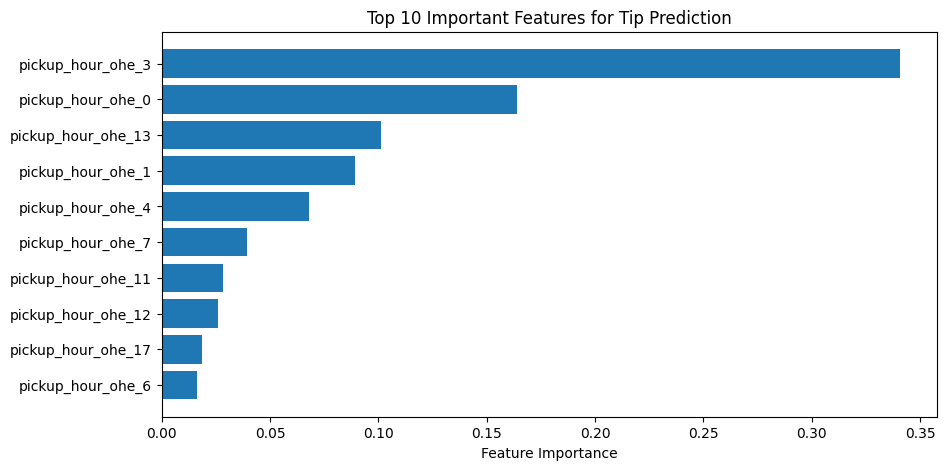

In [21]:
import matplotlib.pyplot as plt

features = [
    'pickup_hour_ohe_3','pickup_hour_ohe_0','pickup_hour_ohe_13','pickup_hour_ohe_1',
    'pickup_hour_ohe_4','pickup_hour_ohe_7','pickup_hour_ohe_11','pickup_hour_ohe_12',
    'pickup_hour_ohe_17','pickup_hour_ohe_6'
]
importances_values = [0.3407,0.1642,0.1012,0.0893,0.0680,0.0392,0.0285,0.0262,0.0186,0.0165]

plt.figure(figsize=(10,5))
plt.barh(features[::-1], importances_values[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features for Tip Prediction")
plt.show()


In [23]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Index pickup_hour
indexer = StringIndexer(inputCol="pickup_hour", outputCol="pickup_hour_index")
encoder = OneHotEncoder(inputCol="pickup_hour_index", outputCol="pickup_hour_ohe")


In [24]:
selected_features = ['fare_amount', 'trip_distance', 'trip_duration_min', 'pickup_hour_ohe']

assembler = VectorAssembler(inputCols=selected_features, outputCol="features")


In [25]:
rf = RandomForestRegressor(featuresCol="features", labelCol="tip_amount", maxDepth=5, numTrees=20)

pipeline = Pipeline(stages=[indexer, encoder, assembler, rf])


In [26]:
df_sample = df_tip.sample(fraction=0.1, seed=42)
train, test = df_sample.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)
pred = model.transform(test)

from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(labelCol="tip_amount", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(pred)

mae = RegressionEvaluator(
    labelCol="tip_amount",
    predictionCol="prediction",
    metricName="mae"
).evaluate(pred_tip)
r2 = RegressionEvaluator(
    labelCol="tip_amount",
    predictionCol="prediction",
    metricName="r2"
).evaluate(pred_tip)
print("Tip RMSE:", rmse)
# print("Tip prediction RMSE:", rmse)
print("Tip prediction MAE:", mae)
print("Tip prediction R2:", r2)


Tip RMSE: 3.3728425881442012
Tip prediction MAE: 1.9183484117146303
Tip prediction R2: 0.4581064600480915


In [65]:
model.write().overwrite().save("/content/drive/MyDrive/ColabProjects/tip_prediction")

In [73]:
import shutil

src = "/content/drive/MyDrive/ColabProjects/tip_prediction"
dst = "/content/drive/MyDrive/ColabProjects/tip_prediction_zip"

# Create ZIP archive
shutil.make_archive(dst, 'zip', src)

print("Saved as:", dst + ".zip")


Saved as: /content/drive/MyDrive/ColabProjects/tip_prediction_zip.zip


In [74]:
from google.colab import files
files.download("/content/drive/MyDrive/ColabProjects/tip_prediction_zip.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: xlabel='tip_amount', ylabel='prediction'>

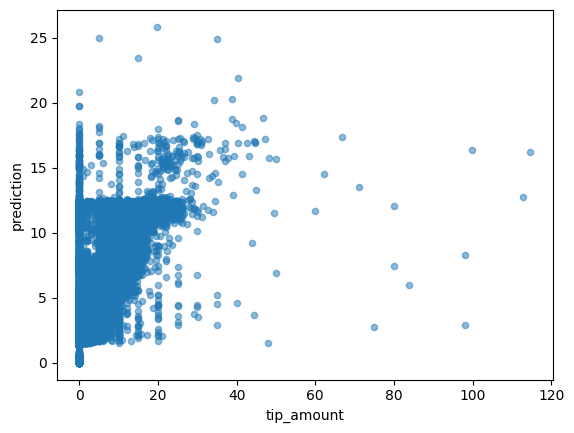

In [28]:
pred_tip.select("tip_amount", "prediction").toPandas().plot.scatter(
    x="tip_amount", y="prediction", alpha=0.5
)


Problem 3 – Payment Type Prediction (Multiclass Classification)

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

df_pay = df_ml.filter(col("payment_type").isNotNull())

pay_indexer = StringIndexer(
    inputCol="payment_type",
    outputCol="payment_type_idx",
    handleInvalid="keep"
)


rf_pay = RandomForestClassifier(
    featuresCol="features",
    labelCol="payment_type_idx",
    maxDepth=10,
    numTrees=100
)


pipeline_pay = Pipeline(
    stages=indexers + [encoder, pay_indexer, assembler, rf_pay]
)

#Train-test split
train_pay, test_pay = df_pay.randomSplit([0.8, 0.2], seed=42)


paramGrid_pay = (ParamGridBuilder()
                 .addGrid(rf_pay.maxDepth, [6, 10, 14])
                 .addGrid(rf_pay.numTrees, [50, 100])
                 .build())


evaluator_multi = MulticlassClassificationEvaluator(
    labelCol="payment_type_idx",
    predictionCol="prediction",
    metricName="accuracy"
)


tvs_pay = TrainValidationSplit(
    estimator=pipeline_pay,
    estimatorParamMaps=paramGrid_pay,
    evaluator=evaluator_multi,
    trainRatio=0.8
)




In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline


indexers_pay = [
    StringIndexer(inputCol="VendorID",          outputCol="VendorID_idx", handleInvalid="keep"),
    StringIndexer(inputCol="RatecodeID",        outputCol="RatecodeID_idx", handleInvalid="keep"),
    StringIndexer(inputCol="PULocationID",      outputCol="PULocationID_idx", handleInvalid="keep"),
    StringIndexer(inputCol="DOLocationID",      outputCol="DOLocationID_idx", handleInvalid="keep"),
    StringIndexer(inputCol="pickup_hour",       outputCol="pickup_hour_idx", handleInvalid="keep"),
    StringIndexer(inputCol="pickup_day_of_week",outputCol="pickup_day_of_week_idx", handleInvalid="keep"),
    StringIndexer(inputCol="payment_type",      outputCol="payment_type_idx", handleInvalid="keep")
]


encoder_pay = OneHotEncoder(
    inputCols=["VendorID_idx","RatecodeID_idx","PULocationID_idx","DOLocationID_idx",
               "pickup_hour_idx","pickup_day_of_week_idx"],
    outputCols=["VendorID_ohe","RatecodeID_ohe","PULocationID_ohe","DOLocationID_ohe",
                "pickup_hour_ohe","pickup_day_of_week_ohe"]
)


assembler_pay = VectorAssembler(
    inputCols=[
        "trip_distance", "fare_amount", "extra", "mta_tax",
        "tolls_amount", "Airport_fee", "trip_duration_min",
        "VendorID_ohe","RatecodeID_ohe","PULocationID_ohe","DOLocationID_ohe",
        "pickup_hour_ohe","pickup_day_of_week_ohe"
    ],
    outputCol="features"
)


rf_pay = RandomForestClassifier(
    featuresCol="features",
    labelCol="payment_type_idx",
    maxDepth=10,
    numTrees=100
)


pipeline_pay = Pipeline(
    stages=indexers_pay + [encoder_pay, assembler_pay, rf_pay]
)


In [36]:
train_pay, test_pay = df_pay.randomSplit([0.8, 0.2], seed=42)

model_pay = pipeline_pay.fit(train_pay)

pred_pay = model_pay.transform(test_pay)

acc_pay = evaluator_multi.evaluate(pred_pay)
f1_pay = MulticlassClassificationEvaluator(
    labelCol="payment_type_idx",
    predictionCol="prediction",
    metricName="f1"
).evaluate(pred_pay)

print("Payment type accuracy:", acc_pay)
print("Payment type F1:", f1_pay)


Payment type accuracy: 0.8651525061937606
Payment type F1: 0.8026033865732463


In [ ]:

model_pay.write().overwrite().save("/content/drive/MyDrive/ColabProjects/payment_prediction")

In [69]:
import shutil

src = "/content/drive/MyDrive/ColabProjects/payment_prediction"
dst = "/content/drive/MyDrive/ColabProjects/payment_prediction_zip"

# Create ZIP archive
shutil.make_archive(dst, 'zip', src)

print("Saved as:", dst + ".zip")


Saved as: /content/drive/MyDrive/ColabProjects/payment_prediction_zip.zip


In [70]:
from google.colab import files
files.download("/content/drive/MyDrive/ColabProjects/payment_prediction_zip.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
 
from pyspark.sql.functions import hour, col

df_ml.groupBy(hour(col("tpep_pickup_datetime")).alias("pickup_hour"), "payment_type") \
     .count() \
     .orderBy("pickup_hour") \
     .show()

df_ml.groupBy("PULocationID", "payment_type").count().show()
df_ml.groupBy("DOLocationID", "payment_type").count().show()




+-----------+------------+-----+
|pickup_hour|payment_type|count|
+-----------+------------+-----+
|          0|           4| 1858|
|          0|           2| 7958|
|          0|           3|  421|
|          0|           1|68941|
|          1|           3|  281|
|          1|           4| 1137|
|          1|           1|42802|
|          1|           2| 4813|
|          2|           2| 3152|
|          2|           4|  751|
|          2|           1|27494|
|          2|           3|  195|
|          3|           3|  139|
|          3|           4|  543|
|          3|           1|17107|
|          3|           2| 2137|
|          4|           2| 2023|
|          4|           1|11327|
|          4|           4|  456|
|          4|           3|  125|
+-----------+------------+-----+
only showing top 20 rows

+------------+------------+-----+
|PULocationID|payment_type|count|
+------------+------------+-----+
|         261|           1|13278|
|         127|           1|  287|
|         24

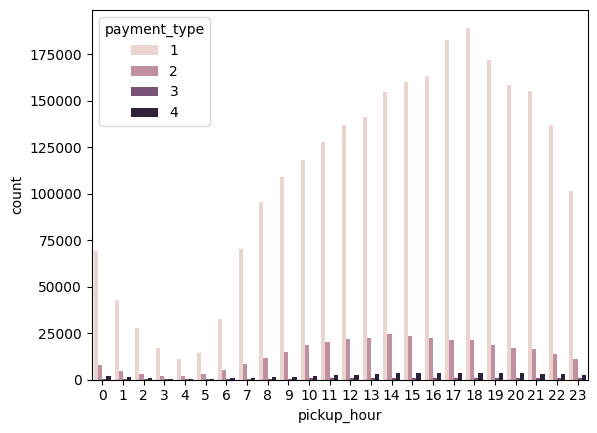

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df_ml.select("pickup_hour", "payment_type").toPandas()
sns.countplot(x="pickup_hour", hue="payment_type", data=pdf)
plt.show()


In [ ]:
from pyspark.sql.functions import lit, unix_timestamp, hour, dayofweek

 
new_trip_df = new_trip_df \
    .withColumn("extra", lit(0.0)) \
    .withColumn("mta_tax", lit(0.0)) \
    .withColumn("Airport_fee", lit(0.0))
 
new_trip_df = new_trip_df.withColumn(
    "trip_duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime"))/60
)
new_trip_df = new_trip_df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
new_trip_df = new_trip_df.withColumn("pickup_day_of_week", dayofweek("tpep_pickup_datetime"))

 
# predictions = model_pay.transform(new_trip_df)
# predictions.select("prediction", "payment_type_idx").show()


In [ ]:
from pyspark.ml.feature import IndexToString

 
payment_indexer_model = model_pay.stages[indexers_pay.index(indexers_pay[-1])]

 
converter = IndexToString(
    inputCol="prediction",
    outputCol="predicted_payment_type",
    labels=payment_indexer_model.labels
)

predictions_str = converter.transform(pred_pay)

 
converter_actual = IndexToString(
    inputCol="payment_type_idx",
    outputCol="actual_payment_type",
    labels=payment_indexer_model.labels
)

predictions_str = converter_actual.transform(predictions_str)

 
predictions_str.select("actual_payment_type", "predicted_payment_type").show(10)


+-------------------+----------------------+
|actual_payment_type|predicted_payment_type|
+-------------------+----------------------+
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
|                  1|                     1|
+-------------------+----------------------+
only showing top 10 rows

